In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import warnings
warning = warnings.filterwarnings("ignore")

# Data Loading

In [25]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

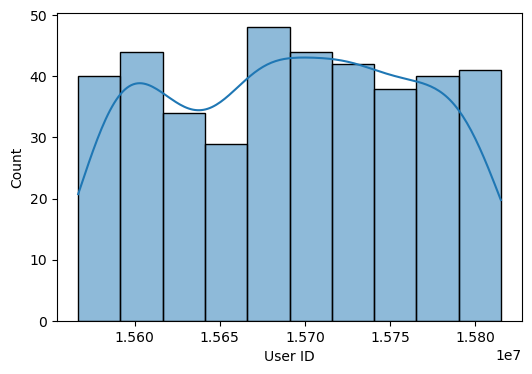

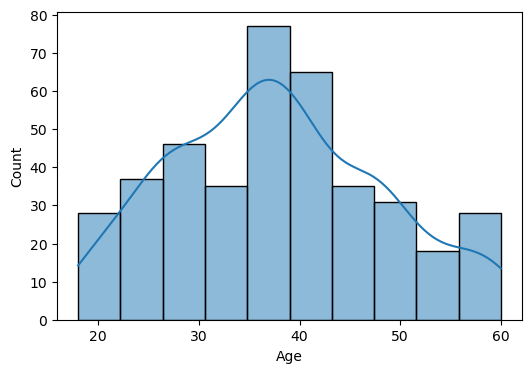

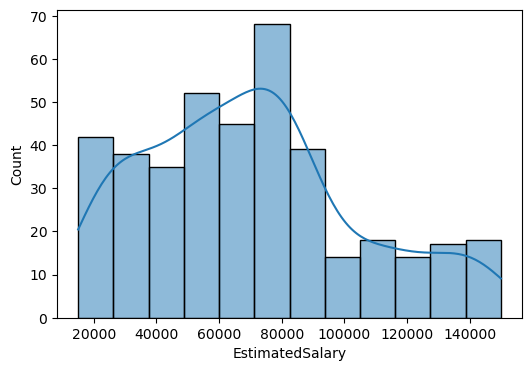

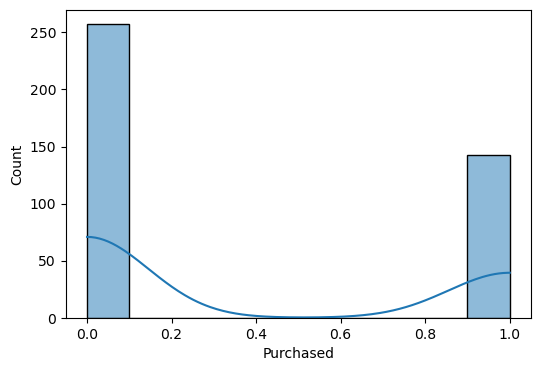

In [29]:
numeric_cols = ["User ID", "Age", "EstimatedSalary", "Purchased"]
for cols in numeric_cols:
    plt.figure(figsize= (6, 4))
    sns.histplot(df[cols], kde= True)

<Axes: xlabel='Gender', ylabel='count'>

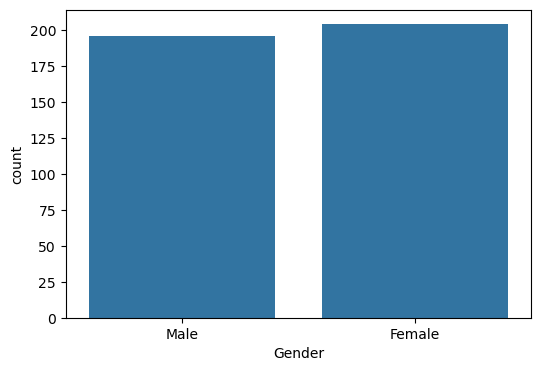

In [30]:
plt.figure(figsize= (6, 4))
sns.countplot(x = df["Gender"])

# Exploratory Data Analysis (EDA)

<Axes: >

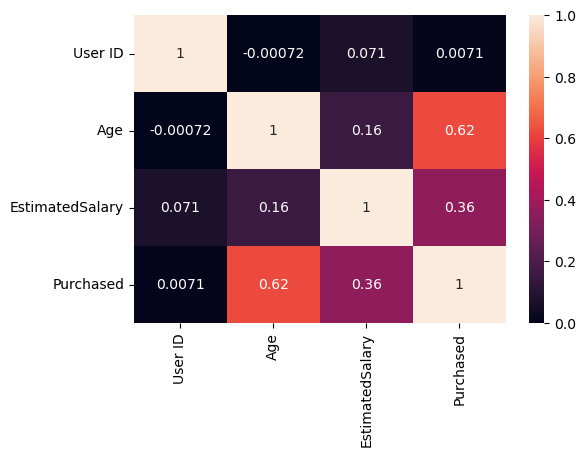

In [31]:
plt.figure(figsize= (6, 4))
sns.heatmap(df.corr(numeric_only= True), annot= True)

# Data Cleaning & Preprocessing

In [32]:
df_clean = df.copy()

In [33]:
df_clean.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [34]:
df_clean.drop(["User ID"], inplace= True, axis= 1)

In [35]:
df_clean.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


# Model Training

In [36]:
X = df.drop("Purchased",axis=1)
y = df.Purchased

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [38]:
cat_cols = X_train.select_dtypes('object')
num_cols = X_train.select_dtypes('number')

In [83]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy= "median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),  
    ("encoder", OneHotEncoder(drop= "first", handle_unknown= "ignore",sparse_output= False))
])

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, make_column_selector(dtype_include= np.number)),
        ("cat", cat_pipeline, make_column_selector(dtype_include= object))
])

In [84]:
linear_pipeline = Pipeline(
    [
    ("preprocessor",  preprocessor),
    ("poly", PolynomialFeatures(degree= 2, include_bias= False)),
    ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001CED383BA10>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001CED6F9DA90>)])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LogisticRegression())])

In [85]:
y_pred = linear_pipeline.predict(X_test)

In [86]:
from sklearn.metrics import r2_score, mean_squared_error

In [87]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [88]:
print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.6703296703296704
RMSE: 0.27386127875258304


In [ ]:
import pickle

with open("student_performence_predictor.pkl", "wb") as file:
    pickle.dump(linear_pipeline, file)

print("Model successfully save ho gaya!")